In [1]:
# Domain Adaptation Model Testing Notebook
# Load and test trained DA models with comprehensive evaluation

import sys
sys.path.append("..")
import os

import torch
import torch.nn.functional as F
import numpy as np
import yaml
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from tqdm import tqdm

from copy import deepcopy

from src.models.base_models import create_model
from src.models.domain_discriminator import DomainDiscriminator, create_da_model
from src.data.numu_dataset import NuMuDataset, create_numu_dataloader_from_ds

# 0. Experiment selection

In [2]:
# Set up paths and experiment
EXPERIMENT_DIR = Path("../experiments/numu/da_numu_251014_middle_noaug")
DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

print(f"Testing experiment: {EXPERIMENT_DIR.name}")
print(f"Device: {DEVICE}")

SAVING_POSTFIX = "BigMCSample_EqualAtmAtsro"

report_dir = f"{EXPERIMENT_DIR}/report_{SAVING_POSTFIX}"
os.makedirs(report_dir, exist_ok=True)

fig_dir = f"{report_dir}/figures/"
os.makedirs(fig_dir, exist_ok=True)

Testing experiment: da_numu_251014_middle_noaug
Device: cuda:1


In [3]:
# Load configuration files
config_path = EXPERIMENT_DIR / "da_config.yaml"
norm_config_path = EXPERIMENT_DIR / "normalization_config.yaml"

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

with open(norm_config_path, 'r') as f:
    normalization_config = yaml.safe_load(f)

print("Configuration loaded:")
print(f"- Model type: {config['model']['type']}")
print(f"- Feature extractor d_model: {config['model']['feature_extractor']['d_model']}")
print(f"- Seed: {config['experiment']['seed']}")
print(f"- Max hits: {config['data']['max_hits']}")

Configuration loaded:
- Model type: numu
- Feature extractor d_model: 128
- Seed: 42
- Max hits: 500


# 1. Load trained models: basic + domain discriminator

In [4]:
# Load trained models from best checkpoint
checkpoint_path = EXPERIMENT_DIR / "best_da_model.pth"
print(f"Loading checkpoint from: {checkpoint_path}")

checkpoint = torch.load(checkpoint_path, map_location=DEVICE)

# Create and load base model
model = create_model(config['model'])
model.load_state_dict(checkpoint['base_model_state_dict'])
model.to(DEVICE)
model.eval()

# Create and load domain discriminator
feature_dim = config['model']['feature_extractor']['d_model']
domain_discriminator = DomainDiscriminator(
    input_dim=feature_dim,
    **config['domain_adaptation']['domain_discriminator']
)
domain_discriminator.load_state_dict(checkpoint['domain_discriminator_state_dict'])
domain_discriminator.to(DEVICE)
domain_discriminator.eval()

print("Models loaded successfully:")
print(f"- Epoch: {checkpoint.get('epoch', 'unknown')}")
print(f"- Best metric: {checkpoint.get('best_metric', 'unknown')}")
print(f"- Base model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"- Domain discriminator parameters: {sum(p.numel() for p in domain_discriminator.parameters()):,}")

Loading checkpoint from: ../experiments/numu/da_numu_251014_middle_noaug/best_da_model.pth


/tmp/ipykernel_64717/459895799.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=DEVICE)


Models loaded successfully:
- Epoch: 72
- Best metric: 0.980447532231743
- Base model parameters: 541,633
- Domain discriminator parameters: 10,561


# 2. Load data to test on

## 2.1 Source (MC) domain

In [5]:
# Create test dataset (using source domain for classification evaluation)
source_config = config['data']['source_domain']
train_events_per_particle = config['data']['source_domain']['events_per_particle']

# Use validation portion of source data for testing (events model hasn't seen)
test_dataset = NuMuDataset(
    h5_path=source_config['h5_path'],
    events_per_particle={'muatm_2020': 500_000, 'nue2_2020': 250_000, 'nuatm_2020': 250_000},  # Test portion
    particle_types=source_config['particle_types'],
    neutrino_types=source_config['neutrino_types'],
    max_hits=config['data']['max_hits'],
    sampling_config={
        'muatm_2020': {'mode': 'range', 'start_event': train_events_per_particle['muatm_2020']},
        'nue2_2020': {'mode': 'range', 'start_event': train_events_per_particle['nue2_2020']},
        'nuatm_2020': {'mode': 'range', 'start_event': train_events_per_particle['nuatm_2020']}
        },
    device='cuda:1',
    shuffle_events=False
)
print(f"Test dataset created with {len(test_dataset)} events")
print(f"Particle distribution:")
for particle in source_config['particle_types']:
    count = sum(1 for i in range(len(test_dataset)) if test_dataset.event_ids[i].split(":")[0] == particle)
    print(f"  {particle}: {count:,} events")
    
    
# Create test dataloader
test_dataloader = create_numu_dataloader_from_ds(
    dataset=test_dataset,
    batch_size=256,
    normalization_config=normalization_config,
    augmentation_config=None,  # No augmentation for testing
    num_workers=0,
    shuffle=False,
    shuffle_batch=False
)
print(f"Test dataloader created:")
print(f"- Batch size: {test_dataloader.batch_size}")
print(f"- Number of batches: {len(test_dataloader)}")
print(f"- Total events: {len(test_dataset)}")
print(f"- Normalization: {normalization_config['feature_names']}")
print(f"- Means: {normalization_config['means']}")
print(f"- Stds: {normalization_config['stds']}")

Test dataset created with 1000000 events
Particle distribution:
  muatm_2020: 500,000 events
  nue2_2020: 250,000 events
  nuatm_2020: 250,000 events
Test dataloader created:
- Batch size: 256
- Number of batches: 3907
- Total events: 1000000
- Normalization: ['amplitude', 'time', 'x', 'y', 'z']
- Means: [2.0, 0.0, 0.0, 0.0, 0.0]
- Stds: [60.0, 1370.0, 40.0, 40.0, 150.0]


## 2.2 Target (EXP) domain

In [6]:
# Create a sample of target domain data for domain discrimination test
target_config = config['data']['target_domain']
target_dataset = NuMuDataset(
    h5_path=target_config['h5_path'],
    particle_types=target_config['particle_types'],
    neutrino_types=target_config.get('neutrino_types', []),
    sampling_config={
        'exp': {
            'mode': 'range', 'start_event': target_config['events_per_particle']['exp']
                }},
    events_per_particle={'exp': 500_000},  # Small sample
    max_hits=config['data']['max_hits'],
    device='cuda:1',
    shuffle_events=False
)

target_dataloader = create_numu_dataloader_from_ds(
    dataset=target_dataset,
    batch_size=256,
    normalization_config=normalization_config,
    shuffle_batch=False,
    augmentation_config=None,
    num_workers=0,
    shuffle=False
)

In [7]:
print(f"Target Test dataloader created:")
print(f"- Batch size: {target_dataloader.batch_size}")
print(f"- Number of batches: {len(target_dataloader)}")
print(f"- Total events: {len(target_dataset)}")

Target Test dataloader created:
- Batch size: 256
- Number of batches: 1368
- Total events: 349976


# 3. Make predctions and extract meta-info

## 3.1 Source (MC) domain

In [8]:
# Make predictions on test data
print("Making predictions...")

all_predictions = []
all_probabilities = []
all_labels = []
all_features = []
all_magic_numbers = []
all_channels_ids = []

with torch.no_grad():
    for batch in tqdm(test_dataloader, miniters=50):
        # Get feature representations and predictions
        feature_repr = model.get_feature_representation(batch)
        logits = model.classifier(feature_repr)
        probabilities_batch = torch.sigmoid(logits)
        predictions_batch = (probabilities_batch > 0.5).float()
        
        # Store results
        all_features.append(feature_repr.cpu())
        all_predictions.append(predictions_batch.cpu())
        all_probabilities.append(probabilities_batch.cpu())
        all_labels.append(batch['labels'].cpu())
        all_magic_numbers.append(batch['magic_numbers'])
        all_channels_ids.append(batch['channels_ids'])

# Concatenate all results
features = torch.cat(all_features, dim=0).numpy()
predictions = torch.cat(all_predictions, dim=0).numpy().flatten()
probabilities = torch.cat(all_probabilities, dim=0).numpy().flatten()
labels = torch.cat(all_labels, dim=0).numpy().flatten()
magic_numbers = []
for values in all_magic_numbers:
    magic_numbers += values
channels_ids = []
for values in all_channels_ids:
    channels_ids += values

print(f"Predictions complete:")
print(f"- Features shape: {features.shape}")
print(f"- Predictions shape: {predictions.shape}")
print(f"- Labels shape: {labels.shape}")
print(f"- Neutrino prediction rate: {np.mean(predictions):.3f}")
print(f"- True neutrino rate: {np.mean(labels):.3f}")

Making predictions...


  0%|          | 0/3907 [00:00<?, ?it/s]/home/albert/miniconda3/envs/baikal25/lib/python3.10/site-packages/torch/nn/modules/transformer.py:502: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647382455/work/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(
100%|██████████| 3907/3907 [01:49<00:00, 35.79it/s]


Predictions complete:
- Features shape: (1000000, 128)
- Predictions shape: (1000000,)
- Labels shape: (1000000,)
- Neutrino prediction rate: 0.545
- True neutrino rate: 0.500


In [9]:
signal_hit_nums = np.asarray([(numbers!=0).sum() for numbers in magic_numbers])
signal_string_nums = np.asarray([np.unique(ids[numbers!=0]//36).size for numbers, ids in zip(magic_numbers, channels_ids)])

## 3.2 Target (EXP) domain

In [10]:
# Source features (limited sample)
source_features_mu = torch.tensor(features[~labels], device=DEVICE)

# Target features
target_features = []
with torch.no_grad():
    for batch in tqdm(target_dataloader, miniters=50):
        feature_repr = model.get_feature_representation(batch)
        target_features.append(feature_repr)

# Combine and test domain discrimination
target_features = torch.cat(target_features, dim=0)

all_domain_features = torch.cat([source_features_mu, target_features], dim=0)#.to(DEVICE)
domain_labels = torch.cat([
    torch.zeros(source_features_mu.shape[0]),  # 0 = source
    torch.ones(target_features.shape[0])    # 1 = target
], dim=0)

# Get domain predictions
with torch.no_grad():
    domain_logits = domain_discriminator(all_domain_features)
    domain_probs = torch.sigmoid(domain_logits).cpu().numpy().flatten()
    domain_preds = (domain_probs > 0.5).astype(float)

domain_accuracy = accuracy_score(domain_labels.numpy(), domain_preds)
domain_auc = roc_auc_score(domain_labels.numpy(), domain_probs)
print(f"Domain discrimination accuracy: {domain_accuracy:.4f}")
print(f"Domain discrimination AUC: {domain_auc:.4f}")
print(f"Note: Lower accuracy indicates better domain adaptation")
print(f"Source samples: {source_features_mu.shape[0]:,}")
print(f"Target samples: {target_features.shape[0]:,}")

100%|██████████| 1368/1368 [00:36<00:00, 37.41it/s]


Domain discrimination accuracy: 0.5800
Domain discrimination AUC: 0.5651
Note: Lower accuracy indicates better domain adaptation
Source samples: 500,000
Target samples: 349,976


# 4. Plots and analysis

## 4.1 NuMu classification

### Metrics dict

In [11]:
# Calculate comprehensive metrics
print("=== Classification Metrics ===")


for h, s in [(0, 0), (5,0), (8,0), (16,0)]:
    mask = (signal_hit_nums>=h)
    labels_masked, probabilities_masked, predictions_mask = labels[mask], probabilities[mask], predictions[mask]

    # Basic metrics
    accuracy = accuracy_score(labels_masked, predictions_mask)
    precision = precision_score(labels_masked, predictions_mask, average='binary')
    recall = recall_score(labels_masked, predictions_mask, average='binary')
    f1 = f1_score(labels_masked, predictions_mask, average='binary')
    auc = roc_auc_score(labels_masked, probabilities_masked)

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"AUC:       {auc:.4f}")

    # Per-class metrics
    precision_muon = precision_score(labels_masked, predictions_mask, pos_label=0)
    precision_neutrino = precision_score(labels_masked, predictions_mask, pos_label=1)
    recall_muon = recall_score(labels_masked, predictions_mask, pos_label=0)
    recall_neutrino = recall_score(labels_masked, predictions_mask, pos_label=1)

    print(f"\nPer-class metrics:")
    print(f"Muon     - Precision: {precision_muon:.4f}, Recall: {recall_muon:.4f}")
    print(f"Neutrino - Precision: {precision_neutrino:.4f}, Recall: {recall_neutrino:.4f}")

    # Confusion matrix
    cm = confusion_matrix(labels_masked, predictions_mask)
    print(f"\nConfusion Matrix:")
    print(f"                 Predicted")
    print(f"                Muon  Neutrino")
    print(f"Actual Muon     {cm[0,0]:5d}  {cm[0,1]:5d}")
    print(f"    Neutrino    {cm[1,0]:5d}  {cm[1,1]:5d}")

    # Class distribution
    total_muons = np.sum(labels_masked == 0)
    total_neutrinos = np.sum(labels_masked == 1)
    print(f"\nClass distribution:")
    print(f"Total muons: {total_muons:,}")
    print(f"Total neutrinos: {total_neutrinos:,}")
    print(f"Balance: {total_neutrinos/(total_muons+total_neutrinos):.3f}")
    
    # Save results
    results_dict = {
        'experiment': EXPERIMENT_DIR.name,
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1),
        'auc': float(auc),
        'precision_muon': float(precision_muon),
        'precision_neutrino': float(precision_neutrino),
        'recall_muon': float(recall_muon),
        'recall_neutrino': float(recall_neutrino),
        'confusion_matrix': cm.tolist(),
        'total_muons': int(total_muons),
        'total_neutrinos': int(total_neutrinos),
        'test_events': len(predictions)
    }
    # Save to file
    results_path = f"{report_dir}/test_results_h{h}_s{s}.yaml"
    with open(results_path, 'w') as f:
        yaml.dump(results_dict, f, default_flow_style=False, indent=2, sort_keys=False)

    print(f"\nResults saved to: {results_path}")

=== Classification Metrics ===
Accuracy:  0.9155
Precision: 0.8815
Recall:    0.9601
F1 Score:  0.9191
AUC:       0.9804

Per-class metrics:
Muon     - Precision: 0.9562, Recall: 0.8710
Neutrino - Precision: 0.8815, Recall: 0.9601

Confusion Matrix:
                 Predicted
                Muon  Neutrino
Actual Muon     435481  64519
    Neutrino    19971  480029

Class distribution:
Total muons: 500,000
Total neutrinos: 500,000
Balance: 0.500

Results saved to: ../experiments/numu/da_numu_251014_middle_noaug/report_BigMCSample_EqualAtmAtsro/test_results_h0_s0.yaml
Accuracy:  0.9728
Precision: 0.9580
Recall:    0.9940
F1 Score:  0.9756
AUC:       0.9978

Per-class metrics:
Muon     - Precision: 0.9923, Recall: 0.9470
Neutrino - Precision: 0.9580, Recall: 0.9940

Confusion Matrix:
                 Predicted
                Muon  Neutrino
Actual Muon     217147  12150
    Neutrino     1682  276864

Class distribution:
Total muons: 229,297
Total neutrinos: 278,546
Balance: 0.548

Result

### Confusion matricies

In [12]:
treshold = 0.5
for h, s in [(0, 0), (5,0), (8,0), (16,0)]:
    mask = (signal_hit_nums>=h) & (signal_string_nums>=s)
    labels_masked, probabilities_masked = labels[mask], probabilities[mask]
    predictions_mask = (probabilities_masked>=treshold)

    print(f"\nResults for Hits>={h}, Stings>={s}")
    # Confusion matrix
    cm = confusion_matrix(labels_masked, predictions_mask)
    print(f"Confusion Matrix:")
    print(f"                 Predicted")
    print(f"                Muon  Neutrino")
    print(f"Actual Muon     {cm[0,0]:5d}  {cm[0,1]:5d}")
    print(f"    Neutrino    {cm[1,0]:5d}  {cm[1,1]:5d}")

    # Create figure
    plt.figure(figsize=(8,6))

    # Create heatmap
    sns.heatmap(cm, annot=True, fmt=',d',
                cmap="Blues", square=True, linewidths=0.5,
                cbar_kws={"shrink": 0.8}, annot_kws={"size": 12})

    # Customize plot
    plt.title("Nu-EAS Confusion Matrix", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')

    # Set labels if provided
    class_labels = ['EAS', 'Nu']
    plt.xticks(np.arange(len(class_labels)) + 0.5, class_labels, rotation=45)
    plt.yticks(np.arange(len(class_labels)) + 0.5, class_labels, rotation=0)
    plt.tight_layout()
    numu_cm_fig = plt.gcf()
    numu_cm_fig.savefig(f"{fig_dir}/cm_h{h}_s{s}_tr{treshold:.3f}.png")
    plt.close()


Results for Hits>=0, Stings>=0
Confusion Matrix:
                 Predicted
                Muon  Neutrino
Actual Muon     435481  64519
    Neutrino    19971  480029

Results for Hits>=5, Stings>=0
Confusion Matrix:
                 Predicted
                Muon  Neutrino
Actual Muon     217147  12150
    Neutrino     1682  276864

Results for Hits>=8, Stings>=0
Confusion Matrix:
                 Predicted
                Muon  Neutrino
Actual Muon     115377   3079
    Neutrino      329  150137

Results for Hits>=16, Stings>=0
Confusion Matrix:
                 Predicted
                Muon  Neutrino
Actual Muon     33834    209
    Neutrino       12  50712


### ROC curves

In [13]:
_ = plt.figure(figsize=(8,8))
#plt.ylim(0.8,1.01)

roc_curves = []
for h, s,color in [(0, 0, 'red'), (5,0,'orange'), (8,0,'green'), (16,0,'lightgreen')]:
    mask = (signal_hit_nums>=h) & (signal_string_nums>=s)
    labels_masked, probabilities_masked, predictions_mask = labels[mask], probabilities[mask], predictions[mask]
    fpr, tpr, thresholds = roc_curve(labels_masked, probabilities_masked)
    auc = roc_auc_score(labels_masked, probabilities_masked)
    acc = accuracy_score(labels_masked, predictions_mask)
    
    geq = r"$\geq$"
    if h==0 and s==0:
        label_plot = f"No cuts\nAUC={auc:.4f}"
    elif s==0:
        label_plot = f"Hits{geq}{h}\nAUC={auc:.4f}"
    elif h==0:
        label_plot = f"Strings{geq}{s}\nAUC={auc:.4f}"
    else:
        label_plot = f"Hits{geq}{h}, Strings{geq}{s}\nAUC={auc:.4f}"
    print(label_plot)
    print(f"\tFPR at 99% TPR: {fpr[tpr>=0.99][0]:.3f}. Suppression to {1/fpr[tpr>=0.99][0]:.1f} times!")
    print(f"\tAccuracy: {acc*100:.2f}%")
    roc_plot, = plt.plot(fpr, tpr, ls='-', color=color, lw=2, label=label_plot)
    roc_curves.append(roc_plot)

# Plot roc using noise only
mask = (signal_hit_nums==0)
labels_masked, probabilities_masked, predictions_mask = labels[mask], probabilities[mask], predictions[mask]
fpr, tpr, thresholds = roc_curve(labels_masked, probabilities_masked)
auc = roc_auc_score(labels_masked, probabilities_masked)
noise_only_line, = plt.plot(fpr, tpr, color='grey', lw=2, label="Noise only: Hits=0")

# Plot diagonal reference line
random_line, = plt.plot(np.linspace(0,1,1000), np.linspace(0,1,1000), 'k--', lw=1, alpha=1., label='Random Classifier')
plt.hlines(0.99, 0, 1, ls='--', lw=1, color='blue', label='Nu TPR=99%')

legend = plt.legend(loc="lower right", fontsize=9, frameon=True, fancybox=True, shadow=True, framealpha=0.6)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Nu Recall)")
plt.title("ROC Curve")

plt.minorticks_on()
plt.grid(which='both', axis='y', alpha=1., linestyle=':')
plt.grid(which='major', axis='x', alpha=1., linestyle=':')
# Save first state
plt.tight_layout()
current_fig = plt.gcf()
current_fig.savefig(f"{fig_dir}/roc_curve.png")
#plt.show(False)

plt.title("ROC Curve (Log FPR)")
plt.xscale('log')
plt.ylim(0.1,1.)
noise_only_line.remove()
for roc_plot in roc_curves:
    roc_plot.set_marker('*')
    roc_plot.set_markersize(3.)
    roc_plot.set_linewidth(0.8)
legend = plt.legend(loc="lower right", fontsize=9, frameon=True, fancybox=True, shadow=True, framealpha=0.6)
# Save second state
plt.tight_layout()
current_fig = plt.gcf()
current_fig.savefig(f"{fig_dir}/roc_curve_log.png")
#plt.show(False)


plt.title("ROC Curve (Log FPR, closer look)")
plt.xscale('log')
plt.ylim(0.8,1.)
plt.xlim(0.001)

# Save third state
plt.tight_layout()
random_line.remove()
current_fig = plt.gcf()
current_fig.savefig(f"{fig_dir}/roc_curve_close.png")
#plt.show(False)
plt.close()

No cuts
AUC=0.9804
	FPR at 99% TPR: 0.270. Suppression to 3.7 times!
	Accuracy: 91.55%
Hits$\geq$5
AUC=0.9978
	FPR at 99% TPR: 0.039. Suppression to 25.5 times!
	Accuracy: 97.28%
Hits$\geq$8
AUC=0.9994
	FPR at 99% TPR: 0.010. Suppression to 97.2 times!
	Accuracy: 98.73%
Hits$\geq$16
AUC=0.9999
	FPR at 99% TPR: 0.001. Suppression to 1063.8 times!
	Accuracy: 99.74%


## 4.2 Source-Target domain classification

### Confusion matricies

In [14]:
treshold = 0.5
for h, s in [(0, 0), (5,0), (8,0), (16,0)]:
    mask = np.concatenate(
        [
            (signal_hit_nums[~labels]>=h) & (signal_string_nums[~labels]>=s), 
            np.ones(target_features.size(0), dtype=bool)
        ]
    )
    labels_masked, probabilities_masked = domain_labels[mask], domain_probs[mask]
    predictions_mask = (probabilities_masked>=treshold)

    print(f"\nResults for Hits>={h}, Stings>={s}")
    # Confusion matrix
    cm = confusion_matrix(labels_masked, predictions_mask)
    print(f"Confusion Matrix:")
    print(f"                 Predicted")
    print(f"                MC   Exp")
    print(f" MC     {cm[0,0]:5d}  {cm[0,1]:5d}")
    print(f" Exp    {cm[1,0]:5d}  {cm[1,1]:5d}")

    # Create figure
    plt.figure(figsize=(8,6))

    # Create heatmap
    sns.heatmap(cm, annot=True, fmt=',d',
                cmap="Blues", square=True, linewidths=0.5,
                cbar_kws={"shrink": 0.8}, annot_kws={"size": 12})

    # Customize plot
    plt.title("Domain Classifier Confusion Matrix", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')

    # Set labels if provided
    class_labels = ['Simulation', 'Experiment']
    plt.xticks(np.arange(len(class_labels)) + 0.5, class_labels, rotation=45)
    plt.yticks(np.arange(len(class_labels)) + 0.5, class_labels, rotation=0)
    plt.tight_layout()
    numu_cm_fig = plt.gcf()
    numu_cm_fig.savefig(f"{fig_dir}/DA_cm_h{h}_s{s}_tr{treshold:.3f}.png")
    plt.close()


Results for Hits>=0, Stings>=0
Confusion Matrix:
                 Predicted
                MC   Exp
 MC     217562  282438
 Exp    74543  275433

Results for Hits>=5, Stings>=0
Confusion Matrix:
                 Predicted
                MC   Exp
 MC     164379  64918
 Exp    74543  275433

Results for Hits>=8, Stings>=0
Confusion Matrix:
                 Predicted
                MC   Exp
 MC     103441  15015
 Exp    74543  275433

Results for Hits>=16, Stings>=0
Confusion Matrix:
                 Predicted
                MC   Exp
 MC     32984   1059
 Exp    74543  275433



Results for Hits==0


Confusion Matrix:
                 Predicted
                MC   Exp
 MC      3463  43928
 Exp    74543  275433


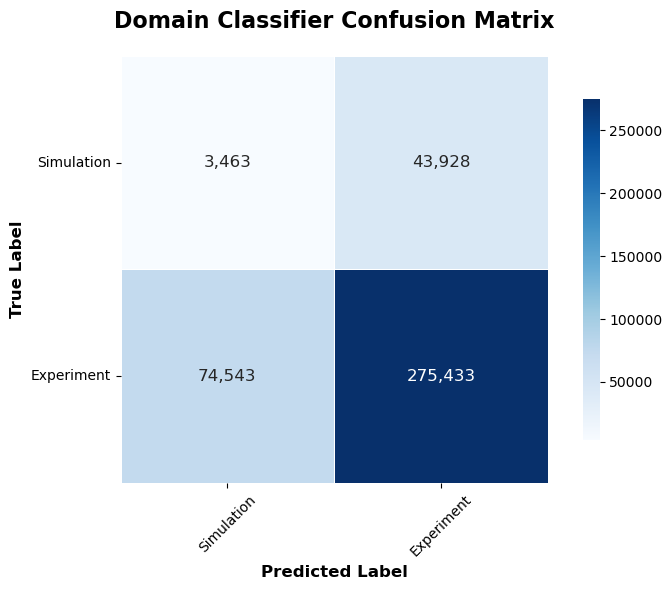

In [15]:
# Where do noise-only events go?
mask = np.concatenate(
        [
            (signal_hit_nums[~labels]==0), 
            np.ones(target_features.size(0), dtype=bool)
        ]
    )
labels_masked, probabilities_masked = domain_labels[mask], domain_probs[mask]
predictions_mask = (probabilities_masked>=treshold)

print(f"\nResults for Hits==0")
# Confusion matrix
cm = confusion_matrix(labels_masked, predictions_mask)
print(f"Confusion Matrix:")
print(f"                 Predicted")
print(f"                MC   Exp")
print(f" MC     {cm[0,0]:5d}  {cm[0,1]:5d}")
print(f" Exp    {cm[1,0]:5d}  {cm[1,1]:5d}")

# Create figure
plt.figure(figsize=(8,6))

# Create heatmap
sns.heatmap(cm, annot=True, fmt=',d',
            cmap="Blues", square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 12})

# Customize plot
plt.title("Domain Classifier Confusion Matrix", fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')

# Set labels if provided
class_labels = ['Simulation', 'Experiment']
plt.xticks(np.arange(len(class_labels)) + 0.5, class_labels, rotation=45)
plt.yticks(np.arange(len(class_labels)) + 0.5, class_labels, rotation=0)
plt.tight_layout()
numu_cm_fig = plt.gcf()
numu_cm_fig.savefig(f"{fig_dir}/DA_cm_noiseonly_tr{treshold:.3f}.png")
plt.show()
plt.close()

### ROC Curves

No cuts
AUC=0.5651
	FPR at 99% TPR: 0.939. Suppression to 1.1 times!
	Accuracy: 58.00%
Hits$\geq$5
AUC=0.7663
	FPR at 99% TPR: 0.868. Suppression to 1.2 times!
	Accuracy: 75.92%
Hits$\geq$8
AUC=0.8857
	FPR at 99% TPR: 0.790. Suppression to 1.3 times!
	Accuracy: 80.88%
Hits$\geq$16
AUC=0.9591
	FPR at 99% TPR: 0.538. Suppression to 1.9 times!
	Accuracy: 80.31%


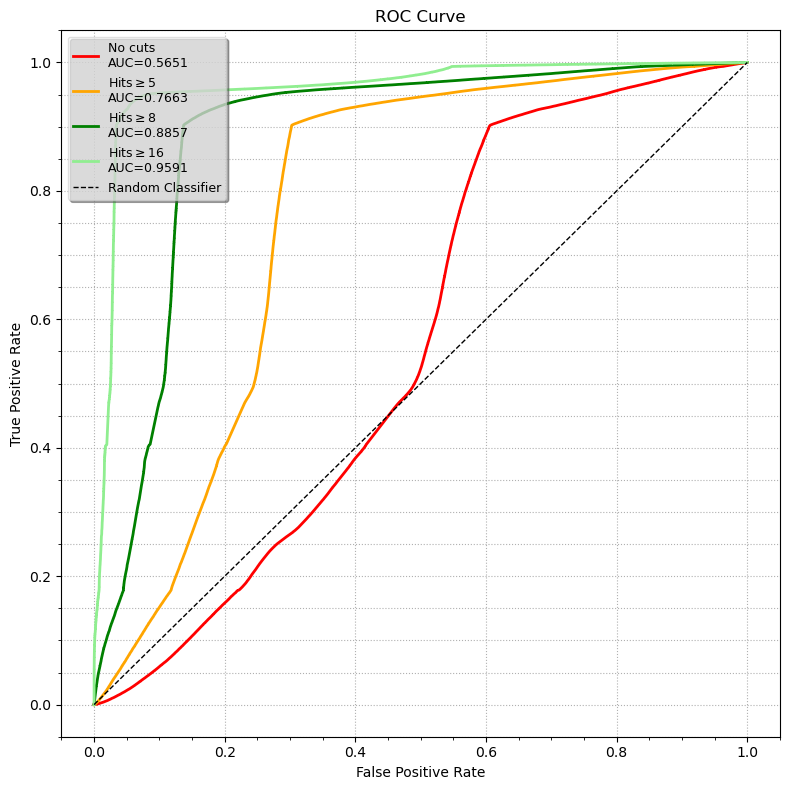

In [16]:
_ = plt.figure(figsize=(8,8))
#plt.ylim(0.8,1.01)

roc_curves = []
for h, s,color in [(0, 0, 'red'), (5,0,'orange'), (8,0,'green'), (16,0,'lightgreen')]:
    mask = np.concatenate(
        [
            (signal_hit_nums[~labels]>=h) & (signal_string_nums[~labels]>=s), 
            np.ones(target_features.size(0), dtype=bool)
        ]
    )
    labels_masked, probabilities_masked = domain_labels[mask], domain_probs[mask]
    fpr, tpr, thresholds = roc_curve(labels_masked, probabilities_masked)
    auc = roc_auc_score(labels_masked, probabilities_masked)
    acc = accuracy_score(labels_masked, (probabilities_masked>=0.5))
    
    geq = r"$\geq$"
    if h==0 and s==0:
        label_plot = f"No cuts\nAUC={auc:.4f}"
    elif s==0:
        label_plot = f"Hits{geq}{h}\nAUC={auc:.4f}"
    elif h==0:
        label_plot = f"Strings{geq}{s}\nAUC={auc:.4f}"
    else:
        label_plot = f"Hits{geq}{h}, Strings{geq}{s}\nAUC={auc:.4f}"
    print(label_plot)
    print(f"\tFPR at 99% TPR: {fpr[tpr>=0.99][0]:.3f}. Suppression to {1/fpr[tpr>=0.99][0]:.1f} times!")
    print(f"\tAccuracy: {acc*100:.2f}%")
    roc_plot, = plt.plot(fpr, tpr, ls='-', color=color, lw=2, label=label_plot)
    roc_curves.append(roc_plot)

# # Plot roc using noise only
# mask = np.concatenate(
#         [
#             (signal_hit_nums[~labels]==0),
#             np.ones(target_features.size(0), dtype=bool)
#         ]
#     )
# labels_masked, probabilities_masked = domain_labels[mask], domain_probs[mask]
# fpr, tpr, thresholds = roc_curve(labels_masked, probabilities_masked)
# auc = roc_auc_score(labels_masked, probabilities_masked)
# noise_only_line, = plt.plot(fpr, tpr, color='grey', lw=2, label="Noise only: Hits=0")

# Plot diagonal reference line
random_line, = plt.plot(np.linspace(0,1,1000), np.linspace(0,1,1000), 'k--', lw=1, alpha=1., label='Random Classifier')

legend = plt.legend(loc="upper left", fontsize=9, frameon=True, fancybox=True, shadow=True, framealpha=0.6)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.minorticks_on()
plt.grid(which='both', axis='y', alpha=1., linestyle=':')
plt.grid(which='major', axis='x', alpha=1., linestyle=':')
# Save first state
plt.tight_layout()
current_fig = plt.gcf()
current_fig.savefig(f"{fig_dir}/discriminator_roc_curves.png")
plt.show()
plt.close()

In [17]:
cm = confusion_matrix(labels_masked, (1-probabilities_masked>=0.49), normalize='true')
cm

array([[0.02999148, 0.97000852],
       [0.7319359 , 0.2680641 ]])

In [18]:
loss = torch.nn.BCELoss()

x = torch.cat((torch.ones(100)*1., torch.ones(100)*1.))
y = torch.cat((torch.zeros(100), torch.ones(100)))
result = loss(y, x)
result.item()

50.0

## 4.3 Predictions distributions

### Classifier p-distr

In [19]:
for h, s in [(0, 0), (5,0), (8,0), (16,0)]:
    mask = (signal_hit_nums>=h) & (signal_string_nums>=s)
    labels_masked, probabilities_masked = labels[mask], probabilities[mask]
    predictions_mask = (probabilities_masked>=treshold)
    
    plt.figure(figsize=(8,6))
    plt.hist(probabilities_masked[labels_masked], bins=100, density=True, log=True, histtype='step', lw=2., label='For Nu only')
    plt.hist(probabilities_masked[~labels_masked], bins=100, color='coral', density=True, log=True, histtype='step', lw=2., label='For EAS only')
    plt.title("Classifier output distribution")
    plt.legend()
    plt.minorticks_on()
    plt.grid(which='both', ls=':', lw=0.9)

    
    plt.xlabel("Prdeicted Nu probability")
    plt.ylabel("Density")
    
    p_distr_fig = plt.gcf()
    p_distr_fig.savefig(f"{fig_dir}/p_distr_h{h}_s{s}.png")
    #plt.show()
    plt.close()

### MC-EXP comparison

In [20]:
# Make p preds for EXP data
print("Making predictions...")

exp_numu_predictions = []
exp_numu_probabilities = []
exp_numu_features = []

with torch.no_grad():
    for batch in tqdm(target_dataloader, miniters=50):
        # Get feature representations and predictions
        feature_repr = model.get_feature_representation(batch)
        logits = model.classifier(feature_repr)
        probabilities_batch = torch.sigmoid(logits)
        predictions_batch = (probabilities_batch > 0.5).float()
        
        # Store results
        exp_numu_features.append(feature_repr.cpu())
        exp_numu_predictions.append(predictions_batch.cpu())
        exp_numu_probabilities.append(probabilities_batch.cpu())

# Concatenate all results
exp_features = torch.cat(exp_numu_features, dim=0).numpy()
exp_predictions = torch.cat(exp_numu_predictions, dim=0).numpy().flatten()
exp_probabilities = torch.cat(exp_numu_probabilities, dim=0).numpy().flatten()

print(f"Predictions complete:")
print(f"- Features shape: {exp_features.shape}")
print(f"- Predictions shape: {exp_predictions.shape}")
print(f"- Neutrino prediction rate: {np.mean(exp_predictions):.3f}")

Making predictions...


100%|██████████| 1368/1368 [00:37<00:00, 36.46it/s]

Predictions complete:
- Features shape: (349976, 128)
- Predictions shape: (349976,)
- Neutrino prediction rate: 0.457


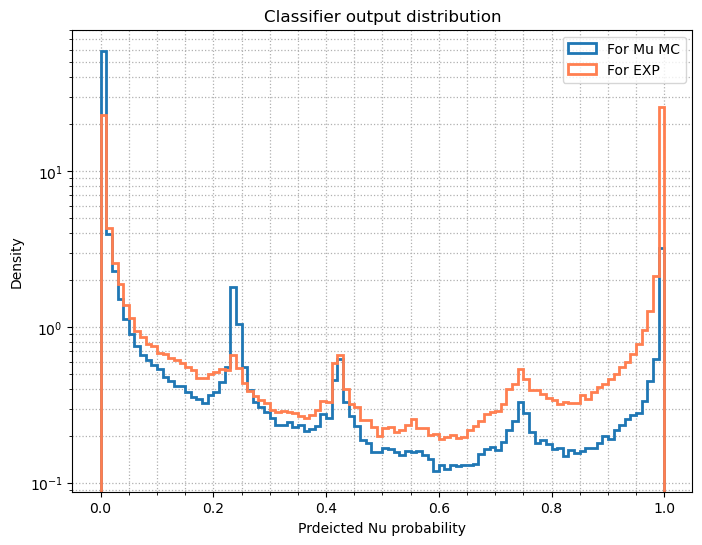

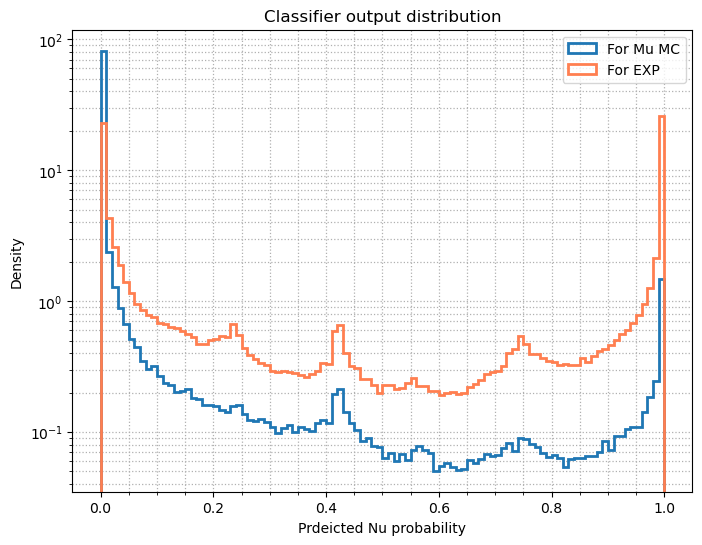

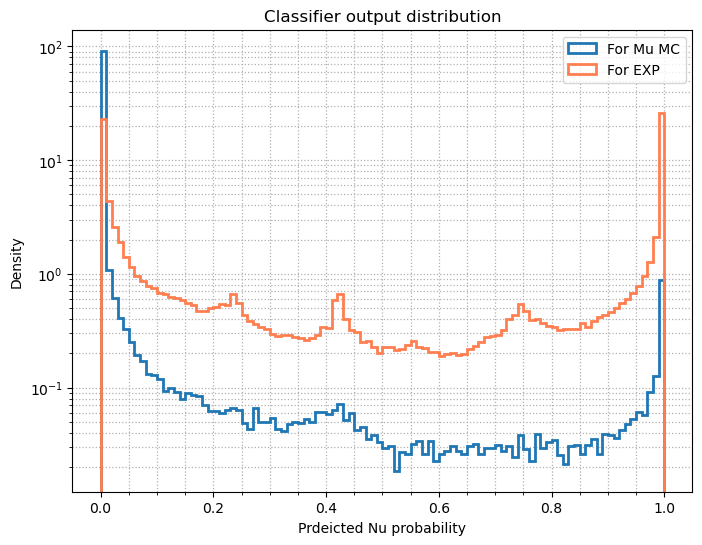

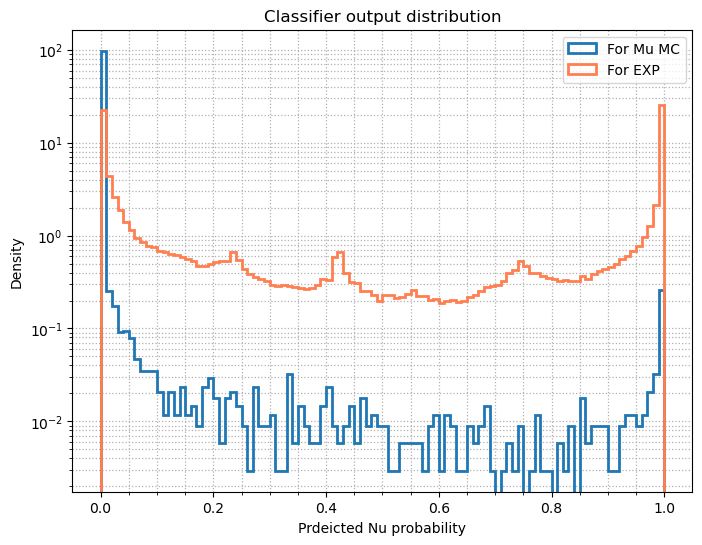

: 

In [ ]:
for h, s in [(0, 0), (5,0), (8,0), (16,0)]:
    mask = (signal_hit_nums>=h) & (signal_string_nums>=s)
    labels_masked, probabilities_masked = labels[mask], probabilities[mask]
    
    plt.figure(figsize=(8,6))
    plt.hist(probabilities_masked[~labels_masked], bins=100, density=True, log=True, histtype='step', lw=2., label='For Mu MC')
    plt.hist(exp_probabilities, color='coral', bins=100, density=True, log=True, histtype='step', lw=2., label='For EXP')
    plt.title("Classifier output distribution")
    plt.legend()
    plt.grid(which='both', ls=':', lw=0.9)

    plt.xlabel("Prdeicted Nu probability")
    plt.ylabel("Density")
    plt.minorticks_on()
    
    p_distr_fig = plt.gcf()
    p_distr_fig.savefig(f"{fig_dir}/MC_EXP_p_distr_h{h}_s{s}.png")
    plt.show()
    plt.close()